# Retrieval-Vergleich: BM25S vs. Embeddings

Gleiches Korpus, gleiche Queries, zwei Retrieval-Verfahren:

- **BM25S** – term-based, zaehlt Wortueberlappung zwischen Query und Chunk (lexikalisch)
- **Embeddings** – dense, vergleicht Vektoren im semantischen Raum

Korpus: `AfD_Parteiprogramm2026.txt`, gechunkt nach Saetzen.

In [ ]:
# Einmalig installieren, falls noch nicht vorhanden:
# %pip install bm25s PyStemmer sentence-transformers pandas numpy

In [29]:
from pathlib import Path

import numpy as np
import pandas as pd


with open("AfD_Parteiprogramm2026.txt", "r", encoding="utf-8") as f:
    TXT_PATH = f.read()

TOP_K = 5
MIN_CHARS = 40   # sehr kurze Fragmente rausfiltern

In [33]:
# creation of chunks from the text file

chunks = TXT_PATH.replace("\n", "").strip().split(".")
chunks[:10]

len_chunks = []

for c in chunks:   
    len_chunks.append(len(c)) 
    if len(c) < MIN_CHARS:
        chunks.remove(c)

print(f"Number of chunks: {len(chunks)}")
print(f"Lengths chunks: {len_chunks}")

Number of chunks: 1638
Lengths chunks: [24, 53, 47, 42, 42, 37, 1, 1, 1, 1, 1, 30, 48, 1, 35, 52, 38, 49, 91, 50, 39, 36, 54, 109, 38, 47, 28, 32, 70, 66, 52, 107, 32, 1, 1, 1, 1, 55, 43, 39, 50, 31, 87, 54, 52, 57, 111, 68, 63, 1, 1, 1, 1, 1, 55, 1, 1, 1, 1, 53, 1, 1, 1, 1, 1, 1, 45, 1, 56, 1, 69, 1, 1, 53, 1, 1, 36, 48, 53, 79, 108, 52, 53, 56, 44, 31, 56, 56, 57, 54, 2, 2, 2, 52, 2, 2, 2, 2, 46, 42, 34, 38, 50, 48, 38, 67, 57, 60, 123, 72, 79, 38, 39, 33, 18, 25, 150, 48, 58, 53, 77, 54, 48, 67, 74, 55, 33, 38, 166, 198, 215, 206, 179, 131, 202, 113, 305, 169, 72, 234, 459, 65, 333, 75, 77, 73, 142, 187, 96, 68, 165, 256, 89, 56, 155, 88, 152, 97, 180, 127, 127, 97, 164, 119, 70, 151, 105, 78, 100, 109, 143, 2, 55, 104, 134, 87, 29, 75, 131, 151, 170, 119, 177, 143, 143, 194, 136, 144, 159, 184, 155, 143, 144, 2, 164, 122, 85, 211, 190, 1, 30, 78, 95, 134, 94, 147, 78, 134, 47, 42, 2, 6, 85, 203, 115, 89, 68, 95, 77, 1, 165, 79, 79, 138, 95, 48, 132, 17, 2, 194, 125, 204, 304, 242, 

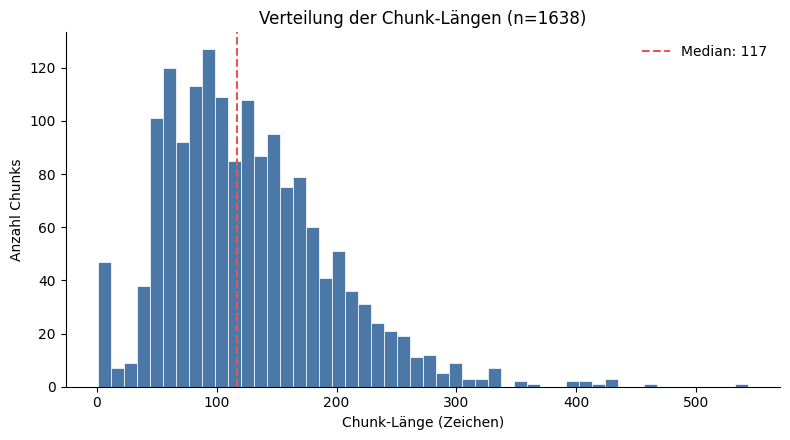

min 1 | p50 117 | p95 250 | max 543


In [34]:
import matplotlib.pyplot as plt
import numpy as np

lengths = [len(c) for c in chunks]          # Zeichen
# lengths = [len(c.split()) for c in chunks]  # Wörter
# lengths = [len(enc.encode(c)) for c in chunks]  # Tokens, z.B. tiktoken

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(lengths, bins=50, color="#4C78A8", edgecolor="white", linewidth=0.5)

med = np.median(lengths)
ax.axvline(med, color="#E45756", linestyle="--", linewidth=1.5,
           label=f"Median: {med:.0f}")

ax.set_xlabel("Chunk-Länge (Zeichen)")
ax.set_ylabel("Anzahl Chunks")
ax.set_title(f"Verteilung der Chunk-Längen (n={len(lengths)})")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

print(f"min {min(lengths)} | p50 {med:.0f} | p95 {np.percentile(lengths, 95):.0f} | max {max(lengths)}")

## <u>1. BM25S – term-based retrieval </u>

BM25 bewertet, wie oft Query-Terme im Chunk vorkommen, gewichtet nach Seltenheit
des Terms im Korpus (IDF) und normiert auf die Chunk-Laenge.

Der Stemmer ist bei Deutsch wichtig: ohne ihn matcht `Klimaschutz` nicht auf
`Klimaschutzpolitik` und `Steuern` nicht auf `Steuer`.

In [ ]:
import bm25s

try:
    import Stemmer
    stemmer = Stemmer.Stemmer("german")
except ImportError:
    stemmer = None
    print("PyStemmer nicht installiert - laeuft ohne Stemming (schwaechere Treffer)")

corpus_tokens = bm25s.tokenize(chunks)

bm25 = bm25s.BM25()
bm25.index(corpus_tokens)
print("BM25-Index gebaut")

In [ ]:
import ollama 
print(ollama.__version__)
print([m.model for m in ollama.list().models])

In [ ]:
def search_bm25(query: str, k: int = TOP_K):
    """Gibt (indices, scores) der k besten Chunks zurueck."""
    query_tokens = bm25.tokenize(query, stopwords="de", show_progress=False)
    idx, scores = bm25.retrieve(query_tokens, k=k, show_progress=False)
    return idx[0], scores[0]


query = "Was ist die Stellungnahme der Partei zum Klimaschutz?"

idx, scores = search_bm25(query)
for i, s in zip(idx, scores):
    print(f"{s:6.2f}  {chunks[i][:140]}")

NameError: name 'query' is not defined

## <u>2. Embeddings – embedding-based retrieval</u>

`paraphrase-multilingual-MiniLM-L12-v2` ist auf mehrsprachigen Paaren trainiert und
versteht Deutsch. Mit `normalize_embeddings=True` sind alle Vektoren auf Laenge 1,
dann ist das Skalarprodukt direkt die Kosinus-Aehnlichkeit.

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(
    chunks,
    batch_size=64,
    normalize_embeddings=True,
    show_progress_bar=True,
)
print(embeddings.shape)   # (n_chunks, 384)

In [ ]:
def search_embed(query: str, k: int = TOP_K):
    """Gibt (indices, scores) der k aehnlichsten Chunks zurueck."""
    q = model.encode([query], normalize_embeddings=True)[0]
    sims = embeddings @ q              # Kosinus-Aehnlichkeit, da normalisiert
    idx = np.argsort(-sims)[:k]
    return idx, sims[idx]


query = "Was ist die Stellungnahme der Partei zum Klimaschutz?"

idx, scores = search_embed(query)
for i, s in zip(idx, scores):
    print(f"{s:6.3f}  {chunks[i][:140]}")

## 4. Vergleich

Die Scores der beiden Verfahren sind **nicht** vergleichbar: BM25 ist unbeschraenkt
nach oben, Kosinus liegt zwischen -1 und 1. Vergleichbar ist nur, *welche* Chunks
oben stehen. Dafuer der Overlap: wie viele der Top-k finden beide Verfahren.

In [ ]:
QUERIES = [
    "Was ist die Stellungnahme der Partei zum Klimaschutz?",
    "Wie steht die Partei zur Europaeischen Union?",
    "Welche Position vertritt die Partei bei der Rente?",
    "Zuwanderung und Asylpolitik",
    "Digitalisierung und kuenstliche Intelligenz",
]


def compare(query: str, k: int = TOP_K, width: int = 110) -> pd.DataFrame:
    b_idx, b_scores = search_bm25(query, k)
    e_idx, e_scores = search_embed(query, k)

    return pd.DataFrame({
        "rank":       range(1, k + 1),
        "bm25_score": np.round(b_scores, 2),
        "bm25_chunk": [chunks[i][:width] for i in b_idx],
        "emb_score":  np.round(e_scores, 3),
        "emb_chunk":  [chunks[i][:width] for i in e_idx],
    }).set_index("rank")


pd.set_option("display.max_colwidth", 120)
compare(QUERIES[0])

In [ ]:
rows = []
for q in QUERIES:
    b_idx, _ = search_bm25(q)
    e_idx, _ = search_embed(q)
    shared = set(b_idx.tolist()) & set(e_idx.tolist())
    rows.append({
        "query": q,
        "overlap": len(shared),
        "overlap_pct": f"{len(shared) / TOP_K:.0%}",
    })

pd.DataFrame(rows)

In [ ]:
# Einzelne Query im Detail anschauen
compare(QUERIES[3])

## Was du in den Ergebnissen sehen solltest

BM25 gewinnt, wenn die Query die Begriffe des Texts woertlich enthaelt, und faellt
aus, sobald du umschreibst. Embeddings finden Umschreibungen, holen aber auch
thematisch benachbarte Chunks, die die Frage nicht beantworten.

Der Satz-Split hat zwei bekannte Schwaechen, die du in den Treffern siehst:
Abkuerzungen und Gliederungsnummern (`12.1 Klimaschutzpolitik`) werden
faelschlich getrennt, und ein einzelner Satz ist oft zu wenig Kontext fuer eine
Antwort. Naechster Schritt waere ein Sliding Window ueber je 3 Saetze mit einem
Satz Ueberlappung, dann laesst sich messen, ob die Trefferqualitaet steigt.